In [131]:
#DATA COLLECTION & ENRICHMENT: Merging the Music & Mental Health survey with Spotify audo features

import pandas as pd
import numpy as np

survey = pd.read_csv('mxmh_survey_results.csv')
spotify = pd.read_csv('dataset.csv')

#Checking the rows and cols of the data
print(f'Survey: {survey.shape}') 
print(f'Spotify: {spotify.shape}')
#survey.head()
spotify.head()



Survey: (736, 33)
Spotify: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [132]:
#CHECKING FOR THE GENRES EXISTED IN EACH DATASET

print("Survey genres:" , survey['Fav genre'].unique())
print("\nSpotify genres:", spotify['track_genre'].unique())

Survey genres: ['Latin' 'Rock' 'Video game music' 'Jazz' 'R&B' 'K pop' 'Country' 'EDM'
 'Hip hop' 'Pop' 'Rap' 'Classical' 'Metal' 'Folk' 'Lofi' 'Gospel']

Spotify genres: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-p

In [133]:
# Audio features per genre from spotify dataset
audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'speechiness']
genre_profiles = spotify.groupby('track_genre')[audio_features].mean()
print(genre_profiles)

             danceability    energy   valence       tempo  acousticness  \
track_genre                                                               
acoustic         0.549593  0.435368  0.424023  119.010624      0.566816   
afrobeat         0.669580  0.702812  0.698619  119.213337      0.270860   
alt-rock         0.534493  0.754173  0.518260  124.634404      0.122162   
alternative      0.559927  0.720030  0.495570  122.232394      0.147820   
ambient          0.367867  0.237162  0.167498  111.113129      0.776790   
...                   ...       ...       ...         ...           ...   
techno           0.684348  0.746413  0.321878  128.255482      0.081414   
trance           0.583409  0.845272  0.276881  133.276726      0.035870   
trip-hop         0.634695  0.622363  0.478069  118.743616      0.225615   
turkish          0.616077  0.609804  0.462314  120.367607      0.321125   
world-music      0.414572  0.532987  0.250295  121.393711      0.299547   

             instrumenta

In [134]:
#create a dict so that I can map the survey genres to spotify genres
genre_map = {
    'Latin':            'latin',
    'Rock':             'rock',
    'Video game music': 'electronic',   # closest available
    'Jazz':             'jazz',
    'R&B':              'r-n-b',
    'K pop':            'k-pop',
    'Country':          'country',
    'EDM':              'edm',
    'Hip hop':          'hip-hop',
    'Pop':              'pop',
    'Rap':              'hip-hop',      # no 'rap' in Spotify, hip-hop is closest
    'Classical':        'classical',
    'Metal':            'metal',
    'Folk':             'folk',
    'Lofi':             'chill',        # closest available
    'Gospel':           'gospel'
}

#Mapping survey genres to Spotify genre names
survey['spotify_genre'] = survey['Fav genre'].map(genre_map)

# Mergind the features onto survey
merged = survey.merge(genre_profiles, left_on='spotify_genre', right_index=True, how='left')

#debugging for merging
print(f"Merged shape: {merged.shape}")
print(f"Unmapped rows: {merged['spotify_genre'].isna().sum()}")
print(f"Missing audio features: {merged['valence'].isna().sum}")

merged[['Fav genre', 'spotify_genre', 'Anxiety', 'Depression',
        'valence', 'energy', 'danceability']].head(8)






Merged shape: (736, 41)
Unmapped rows: 0
Missing audio features: <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
731    False
732    False
733    False
734    False
735    False
Name: valence, Length: 736, dtype: bool>


,Fav genre,spotify_genre,Anxiety,Depression,valence,energy,danceability
0,Latin,latin,3.0,0.0,0.631149,0.727080,0.721902
1,Rock,rock,7.0,2.0,0.538903,0.679071,0.543609
2,Video game music,electronic,7.0,7.0,0.391839,0.694752,0.652945
3,Jazz,jazz,9.0,7.0,0.490289,0.352954,0.509975
4,R&B,r-n-b,7.0,2.0,0.633164,0.638130,0.614388
5,Jazz,jazz,8.0,8.0,0.490289,0.352954,0.509975
6,Video game music,electronic,4.0,8.0,0.391839,0.694752,0.652945
7,K pop,k-pop,5.0,3.0,0.556915,0.675654,0.647732


In [135]:
#Saving the cleaned at merged data, and cleaning the data
import matplotlib.pyplot as plt
import seaborn as sns

#Dropping the rows where mental health scores are missing
merged = merged.dropna(subset=['Anxiety', 'Depression', 'Insomnia', 'OCD'])
print(f"Clean dataset: {merged.shape[0]} rows")

#Save for later use
merged.to_csv('merged_data.csv', index = False)

Clean dataset: 736 rows


In [136]:
# ******** MISSING VALUE AND OUTLIER ANALYSIS ********

# MISSING VALUES

print("****** MISSING VALUES *******")

print(merged[['Anxiety', 'Depression', 'Insomnia', 'OCD'] + audio_features].isna().sum())

#Outlier check using IQR method

print("**** OUTLIER CHECK USING IQR METHOD ****")

for col in ['Anxiety', 'Depression', 'Insomnia', 'OCD']:
    q1 = merged[col].quantile(0.25)
    q3 = merged[col].quantile(0.75)
    iqr = q3-q1
    outliers = merged[(merged[col] < q1 - 1.5*iqr) | (merged[col] > q1 + 1.5*iqr)]
    print(f"{col}: {len(outliers)} outliers  (Q1: {q1:.1f},  Q3: {q3:.1f},  IQR: {iqr:.1f})")


****** MISSING VALUES *******
Anxiety             0
Depression          0
Insomnia            0
OCD                 0
danceability        0
energy              0
valence             0
tempo               0
acousticness        0
instrumentalness    0
speechiness         0
dtype: int64
**** OUTLIER CHECK USING IQR METHOD ****
Anxiety: 0 outliers  (Q1: 4.0,  Q3: 8.0,  IQR: 4.0)
Depression: 45 outliers  (Q1: 2.0,  Q3: 7.0,  IQR: 5.0)
Insomnia: 61 outliers  (Q1: 1.0,  Q3: 6.0,  IQR: 5.0)
OCD: 63 outliers  (Q1: 0.0,  Q3: 5.0,  IQR: 5.0)


In [137]:
for col in ['Depression', 'Insomnia', 'OCD']:
    q1 = merged[col].quantile(0.25)
    q3 = merged[col].quantile(0.75)
    iqr = q3-q1
    low = merged[merged[col] < q1 - 1.5*iqr][col]
    high = merged[merged[col] >q3 + 1.5*iqr][col]
    print(f"{col}: {len(low)} low outliers, {len(high)} high outliers")



Depression: 0 low outliers, 0 high outliers
Insomnia: 0 low outliers, 0 high outliers
OCD: 0 low outliers, 0 high outliers


In [138]:
# *** INDIVIDUAL TRACK-LEVEL FEATURE ASSIGNNENT ****
# Instead of genre average, find the closest Spotify track
# To each respondent usong their self-reported BPM

audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'speechiness']

def get_individual_features(row):
    genre = row['spotify_genre']
    bpm = row['BPM']
    if pd.isna(genre) or pd.isna(bpm):
        return pd.Series([None]*7, index=audio_features)
    genre_tracks = spotify[spotify['track_genre'] == genre].copy()
    if genre_tracks.empty:
        return pd.Series([None]*7, index=audio_features)
    genre_tracks['bpm_diff'] = abs(genre_tracks['tempo'] - bpm)
    closest = genre_tracks.nsmallest(1, 'bpm_diff')
    return closest[audio_features].iloc[0]

print("Assigning individual track features")
merged[audio_features] = merged.apply(get_individual_features, axis=1)
print(f"Done. Missing after assignment: {merged[audio_features[0]].isna().sum()}")
merged[['Fav genre', 'BPM'] + audio_features].head(8)

Assigning individual track features
Done. Missing after assignment: 107


,Fav genre,BPM,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness
0,Latin,156.0,0.755,0.767,0.232,156.001,0.01760,0.000000,0.1060
1,Rock,119.0,0.666,0.935,0.690,118.999,0.00285,0.781000,0.0445
2,Video game music,132.0,0.776,0.895,0.844,132.003,0.03940,0.002670,0.0476
3,Jazz,84.0,0.361,0.116,0.387,84.414,0.92400,0.000004,0.0432
4,R&B,107.0,0.737,0.505,0.959,107.008,0.44700,0.000002,0.0301
5,Jazz,86.0,0.399,0.485,0.376,86.074,0.15500,0.000094,0.0336
6,Video game music,66.0,0.397,0.684,0.870,63.047,0.04860,0.007500,0.0419
7,K pop,95.0,0.696,0.778,0.410,94.996,0.35200,0.000000,0.0585


In [139]:
#but we have 107 missing, so we should have do something for them
print(f"Total rows: {len(merged)}")
print(f"Missing BPM in survey: {merged['BPM'].isna().sum()}")
print(f"BPM range: {merged['BPM'].min()} - {merged['BPM'].max()}")

# For missing rows, fall back to genre average features
genre_profiles = spotify.groupby('track_genre')[audio_features].mean()

def fill_with_genre_average(row):
    for feat in audio_features:
        if pd.isna(row[feat]):
            genre = row['spotify_genre']
            if genre in genre_profiles.index:
                row[feat] = genre_profiles.loc[genre, feat]
    return row

merged = merged.apply(fill_with_genre_average, axis=1)
print(f"\nMissing after fallback fill: {merged[audio_features[0]].isna().sum()}")



Total rows: 736
Missing BPM in survey: 107
BPM range: 0.0 - 999999999.0

Missing after fallback fill: 0


In [140]:
# due to having a bad BPM range, we must do some more data cleaning as well
print(f"Before cleaning - BPM stats:")
print(merged['BPM'].describe())

# Replace unrealistic BPM values with NaN
merged['BPM'] = merged['BPM'].where(
    (merged['BPM'] >= 40) & (merged['BPM'] <= 250), 
    other=np.nan
)

print(f"\nAfter cleaning:")
print(f"Valid BPM rows: {merged['BPM'].notna().sum()}")
print(f"Invalid BPM rows (set to NaN): {merged['BPM'].isna().sum()}")

# Re-run individual feature assignment with clean BPM
print("\nRe-assigning individual track features with clean BPM...")
merged[audio_features] = merged.apply(get_individual_features, axis=1)
print(f"Missing after individual assignment: {merged[audio_features[0]].isna().sum()}")

# Fill remaining missing with genre average fallback
merged = merged.apply(fill_with_genre_average, axis=1)
print(f"Missing after fallback fill: {merged[audio_features[0]].isna().sum()}")



Before cleaning - BPM stats:
count    6.290000e+02
mean     1.589948e+06
std      3.987261e+07
min      0.000000e+00
25%      1.000000e+02
50%      1.200000e+02
75%      1.440000e+02
max      1.000000e+09
Name: BPM, dtype: float64

After cleaning:
Valid BPM rows: 621
Invalid BPM rows (set to NaN): 115

Re-assigning individual track features with clean BPM...
Missing after individual assignment: 115
Missing after fallback fill: 0


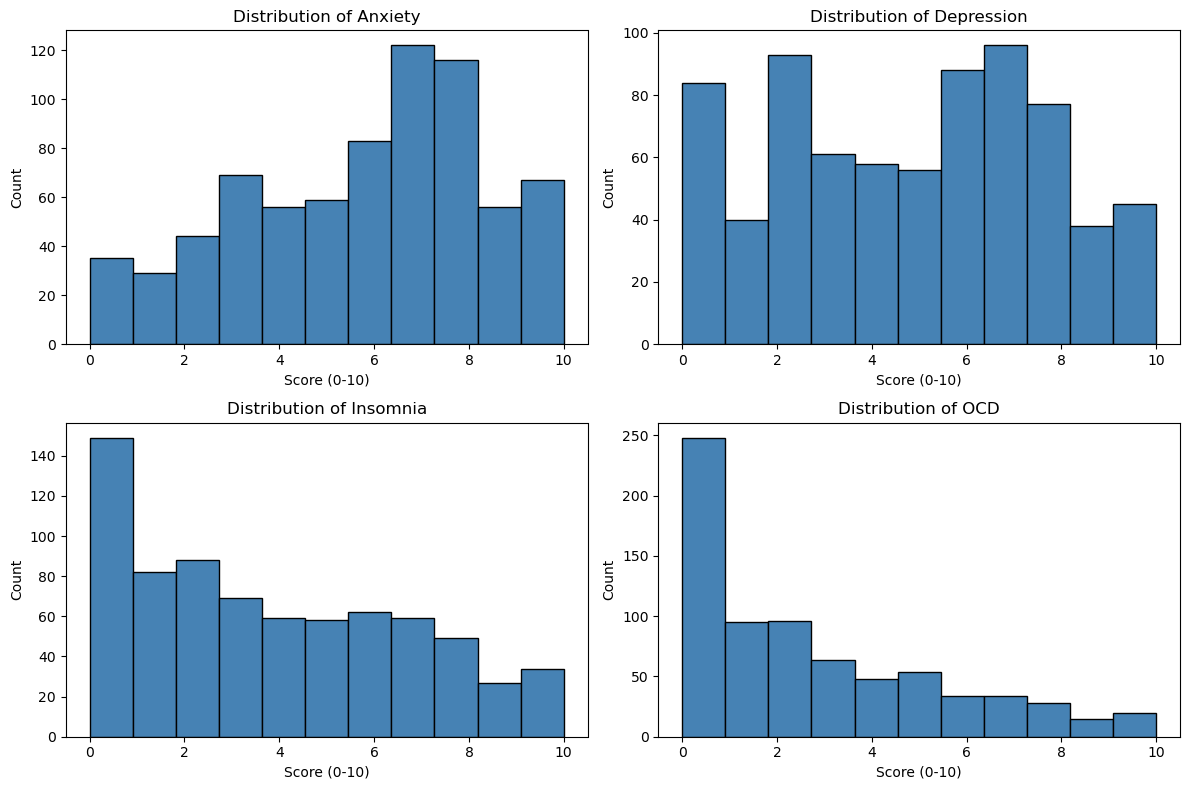

In [141]:
#DISTRIBUTION OF MENTAL HEALTH SCORES WITH HISTOGRAMS
fig, axes = plt.subplots(2,2, figsize=(12,8))
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

for ax, col in zip(axes.flatten(), mh_cols):
    ax.hist(merged[col].dropna(), bins=11, edgecolor='black', color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()    



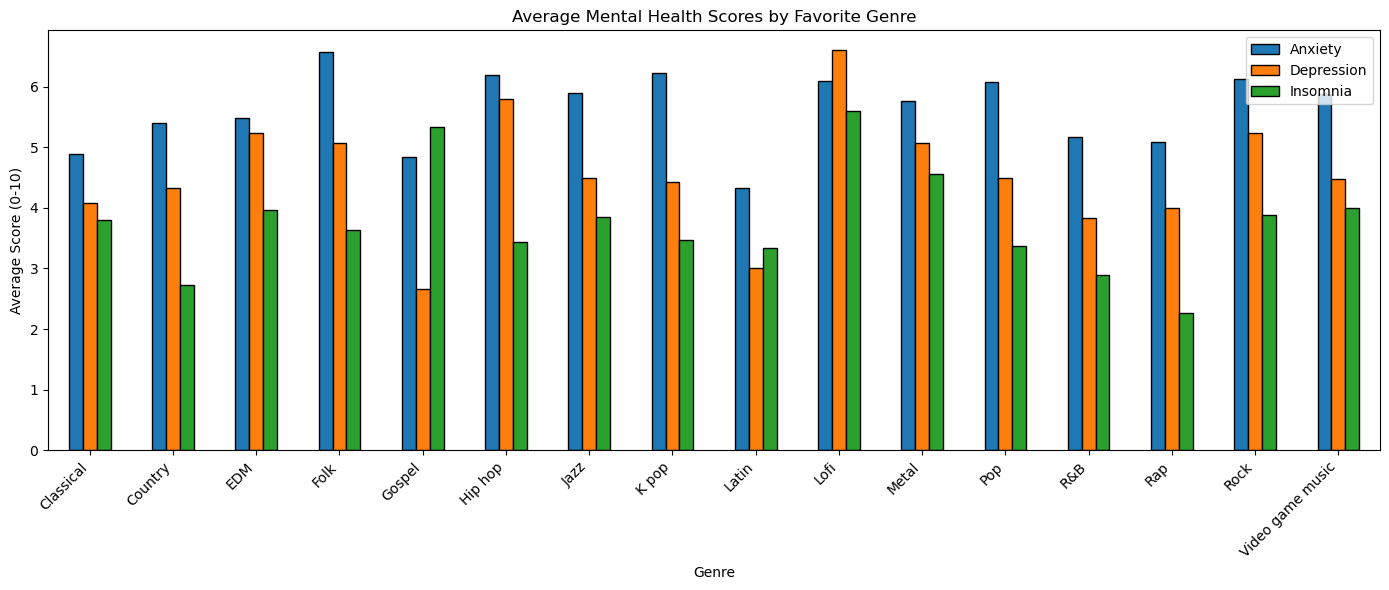

In [142]:
#Average anxiety/depression by favorite genre (bar chart)

genre_mh = merged.groupby('Fav genre')[['Anxiety', 'Depression', 'Insomnia']].mean()

genre_mh.plot(kind = 'bar', figsize=(14,6), edgecolor = 'black')
plt.title('Average Mental Health Scores by Favorite Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score (0-10)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

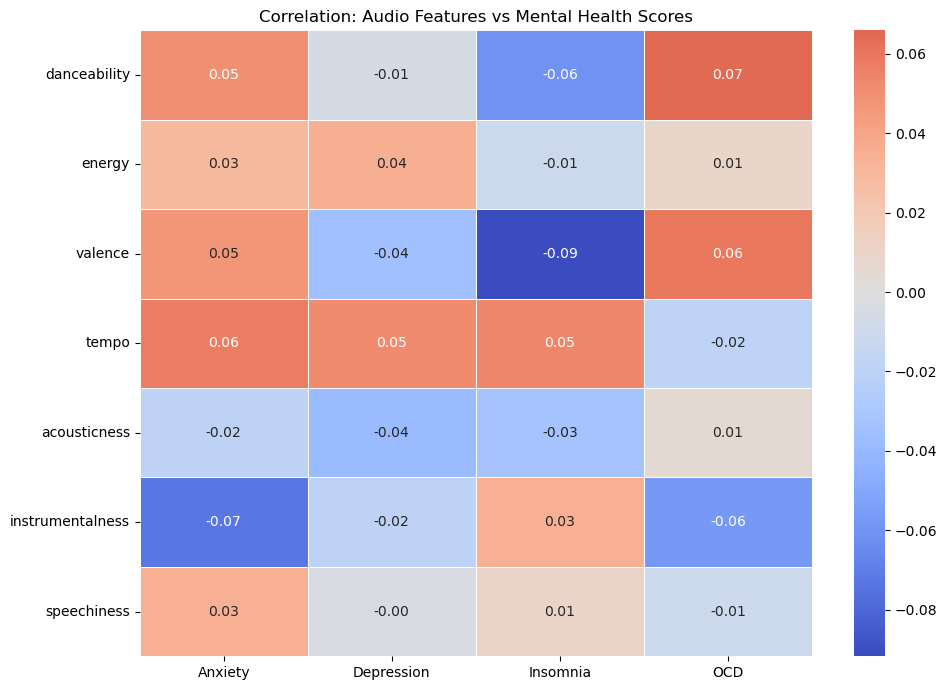

In [143]:
# Correlation heatmap (audio features vs MH scores):

audio_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'speechiness']
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

corr = merged[audio_features + mh_cols].corr().loc[audio_features, mh_cols]

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,linewidths=0.5)
plt.title('Correlation: Audio Features vs Mental Health Scores')
plt.tight_layout()
plt.show()


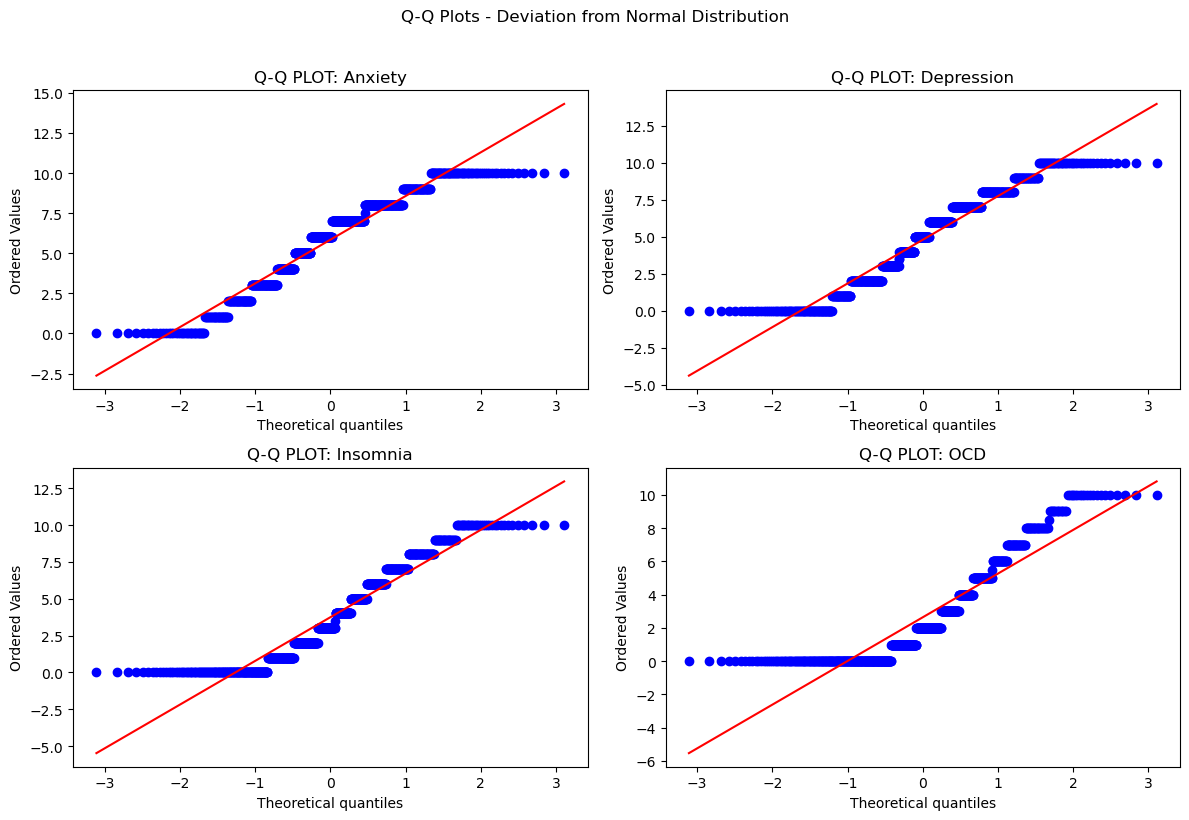

In [144]:
#VISUAL NORMALITY CHECK USING Q-Q plots

import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(2,2, figsize=(12,8))
mh_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']

for ax, col in zip(axes.flatten(), mh_cols):
    stats.probplot(merged[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q PLOT: {col}')
plt.suptitle('Q-Q Plots - Deviation from Normal Distribution', y=1.02)
plt.tight_layout()
plt.show()    

In [145]:
# KRUSKAL-WALLIS HYPOTHESIS TEST

print("****** KRUSKAL-WALLIS TEST ******")
print("H0: Anxiety scores are equal across all favorite genres")
print("H1: Anxiety scores are not equal across all favorite genres at least there is one group has\n")


anxiety_groups = []

grouped_data = merged.groupby('Fav genre')

for genre_name, group_data in grouped_data:
    anxiety_scores = group_data['Anxiety'].values
    anxiety_groups.append(anxiety_scores)

stat, p = stats.kruskal(*anxiety_groups)


print(f"H-statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

print("\nResult: ", end="") 
if p < 0.05:
    print("REJECT H0 — genres differ significantly")
else:
    print("FAIL TO REJECT H0")

****** KRUSKAL-WALLIS TEST ******
H0: Anxiety scores are equal across all favorite genres
H1: Anxiety scores are not equal across all favorite genres at least there is one group has

H-statistic: 17.6151
P-value: 0.283444

Result: FAIL TO REJECT H0


In [146]:
# SPEARMAN CORRELATION BASED ON INDIVIDYAL TRACK FEATURES, CLEAN BPM

print("*** SPEARMAN CORRELATION TEST ***")
print("H0: No monotonic relationship between audio features and mental health scores")
print("H1: A significant monotonic relationship exists\n")

audio_features = ['valence', 'energy', 'danceability', 'acousticness', 'tempo']
targets = ['Anxiety', 'Depression', 'Insomnia']

results = []


for feat in audio_features:
    for target in targets:
        feature_data = merged[feat]
        target_data = merged[target]
        
        # run the Spearman correlation test
        # rho is the correlation coefficient (how strong the link is)
        # p is the p-value (how likely this happened by chance)
        rho, p = stats.spearmanr(feature_data, target_data)
        
        #  checking for statistical significance (p-value less than 0.05)
        if p < 0.05:
            sig = "* significant"
        else:
            sig = ""
            
        current_result = {
            'Feature': feat, 
            'Target': target, 
            'Rho': round(rho, 4), 
            'P-value': round(p, 4), 
            'Result': sig
        }
        
        results.append(current_result)

#displaying
# convert list to panda data frame
results_df = pd.DataFrame(results)

# Print it out as a string, telling Pandas to hide the row numbers (index=False)
print(results_df.to_string(index=False))

*** SPEARMAN CORRELATION TEST ***
H0: No monotonic relationship between audio features and mental health scores
H1: A significant monotonic relationship exists

     Feature     Target     Rho  P-value        Result
     valence    Anxiety  0.0390   0.2903              
     valence Depression -0.0429   0.2451              
     valence   Insomnia -0.0794   0.0314 * significant
      energy    Anxiety  0.0184   0.6183              
      energy Depression  0.0309   0.4032              
      energy   Insomnia -0.0149   0.6874              
danceability    Anxiety  0.0410   0.2664              
danceability Depression -0.0031   0.9333              
danceability   Insomnia -0.0561   0.1281              
acousticness    Anxiety -0.0104   0.7788              
acousticness Depression -0.0722   0.0502              
acousticness   Insomnia -0.0693   0.0602              
       tempo    Anxiety  0.0559   0.1295              
       tempo Depression  0.0647   0.0795              
       tempo  

In [147]:
print("*** MANN-WHITNEY U TEST *** ")
print("H0: Anxiety is equal between people who say music improves vs worsens their mood")
print("H1: There is a difference in anxiety between these two groups\n")

#isolating the data for people who say music 'Improves' their mood

is_improve = merged['Music effects'] == 'Improve'
improve_data = merged[is_improve]

#grab the anxiety column

anxiety_improves_with_blanks = improve_data['Anxiety']

# frop any missing and blank values
anxiety_improves = anxiety_improves_with_blanks.dropna()

# grab the data for people who say music Worsens their mood

is_worsen = merged['Music effects'] == 'Worsen'
worsen_data = merged[is_worsen]

anxiety_worsens_with_blanks = worsen_data['Anxiety']
anxiety_worsens = anxiety_worsens_with_blanks.dropna()

# calculate count and medians for both groups

count_improves = len(anxiety_improves)
median_improves = anxiety_improves.median()
print(f"'Improve' group: n={count_improves}, median={median_improves}")

count_worsens = len(anxiety_worsens)
median_worsens = anxiety_worsens.median()
print(f"'Worsen' group:  n={count_worsens}, median={median_worsens}")

#run the mann whitney u test
stat, p = stats.mannwhitneyu(anxiety_improves, anxiety_worsens, alternative='two-sided')

print(f"\nU-statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

print("\nResult: ", end="")
if p < 0.05:
    print("REJECT H0 — significant difference")
else:
    print("FAIL TO REJECT H0")





*** MANN-WHITNEY U TEST *** 
H0: Anxiety is equal between people who say music improves vs worsens their mood
H1: There is a difference in anxiety between these two groups

'Improve' group: n=542, median=7.0
'Worsen' group:  n=17, median=7.0

U-statistic: 3925.0000
P-value: 0.294861

Result: FAIL TO REJECT H0


NOW WE ARE AT MACHINE LEARNING PHASE FIRST WE HAVE TO SETUP THE PACKAGES IN ORDER TO APPLY ML METHODS


In [148]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score)

NOW FIRST STEP OF OUR MACHINE LEARNING PHASE IS FEATURE ENGINEERING, I AM GOING TO USE BINARY ENCODING
IF ANXIETY SCORE IS BIGGER THAN 6 THAN IT IS TRUE

IN THIS CASE, WE ARE GOING TO SEE THE ANXIETY RATE OF THE PARTICIPANTS RELATED ON THE DATA SATE


In [149]:
merged['high_anxiety'] = (merged['Anxiety'] >=6).astype(int)

print("Class distribution:")
print(merged['high_anxiety'].value_counts())
print(f"\nHigh anxiety rate: {merged['high_anxiety'].mean():.1%}")

Class distribution:
high_anxiety
1    444
0    292
Name: count, dtype: int64

High anxiety rate: 60.3%


NOW WE ARE GOING TO CHOOSE FEATURES USING ONE HOT ENCODING (RECIT 7)

In [150]:
audio_features = ['valence', 'energy', 'danceability', 'acousticness', 'instrumentalness', 'speechiness', 'tempo']

survey_features = ['Age', 'Hours per day', 'BPM']

# ONE HOT ENCODING 

genreDummies = pd.get_dummies(merged['Fav genre'], prefix='genre', drop_first=True)

# Now concatanate the features

df_ml = pd.concat([merged[audio_features + survey_features + ['high_anxiety']], genreDummies], axis=1)
df_ml = df_ml.dropna()

featureCols = audio_features + survey_features + list(genreDummies.columns)
x = df_ml[featureCols]
y = df_ml['high_anxiety']

print(f"Samples after dropping NaN: {len(df_ml)}")
print(f"Number of features: {len(featureCols)}")



Samples after dropping NaN: 621
Number of features: 25


NOW TRAINING AND TESTING SPLIT AND SCALING THE DATA 80 percent train, 20 percent test

In [151]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")


Train: (496, 25), Test: (125, 25)


Now making the decision tree for our dataset

In [152]:
dt_param_grid = {'max_depth': [3,5,7,10, None], 'min_samples_split':[2,5,10]}

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='f1', n_jobs = -1)
dt_grid.fit(x_train, y_train)

print(f" Best parameters: {dt_grid.best_params_}")
print(f" Best CV F1: {dt_grid.best_score_:.4f}") #cross validation f1 score


 Best parameters: {'max_depth': 5, 'min_samples_split': 10}
 Best CV F1: 0.6800


In [153]:
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(x_test)
y_prob_dt = dt_best.predict_proba(x_test)[:,1]

print("***** DECISION TREE TEST SET RESULTS *****")
print(classification_report(y_test, y_pred_dt, target_names=['Low', 'High']))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")


***** DECISION TREE TEST SET RESULTS *****
              precision    recall  f1-score   support

         Low       0.41      0.59      0.49        49
        High       0.64      0.46      0.53        76

    accuracy                           0.51       125
   macro avg       0.53      0.53      0.51       125
weighted avg       0.55      0.51      0.52       125

ROC AUC: 0.5518


OUR MODEL ACURACY IS VERY LOW, SINCE OUR DATA SET IS NOT GOOD FOR EFFECT, IT DID OVERFITTING SINCE 60 PERCENT OF DATABASE IS RELATED WITH ANXIETY, BUT STILL THERE IS NOTHING TO DO WITH, SO MOVING TO KNN BECAUSE WE HAVE TO FOUND THE BEST K VALUE

Best k: 15  (CV F1 = 0.7400)


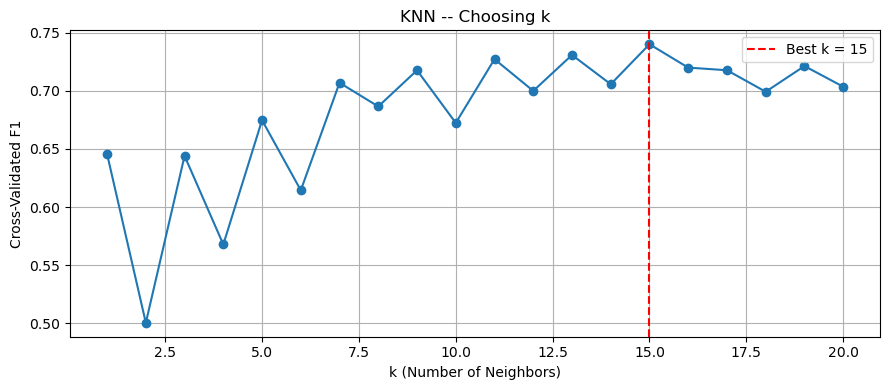

In [154]:
k_values = range(1,21)
cv_scores_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_scaled, y_train, cv=5, scoring='f1')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]
print(f"Best k: {best_k}  (CV F1 = {max(cv_scores_knn):.4f})")

#NOW PLOTTING OUR RESULTS

plt.figure(figsize=(9,4))
plt.plot(list(k_values), cv_scores_knn, marker = 'o')
plt.axvline(x=best_k, color = 'red', linestyle = '--', label = f'Best k = {best_k}')
plt.xlabel ('k (Number of Neighbors)')
plt.ylabel("Cross-Validated F1")
plt.title('KNN -- Choosing k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [155]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(x_train_scaled, y_train)

y_pred_knn = knn_best.predict(x_test_scaled)
y_prob_knn = knn_best.predict_proba(x_test_scaled)[:,1]

print("**** KNN TEST SET RESULTS ****")
print(classification_report(y_test, y_pred_knn, target_names=['Low', 'High']))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_knn):.4f}")


**** KNN TEST SET RESULTS ****
              precision    recall  f1-score   support

         Low       0.44      0.22      0.30        49
        High       0.62      0.82      0.70        76

    accuracy                           0.58       125
   macro avg       0.53      0.52      0.50       125
weighted avg       0.55      0.58      0.54       125

ROC AUC: 0.5541


NOW LOOKING AT RANDOM FOREST IN OUR DATA

In [156]:
rf_param_grid = {'n_estimators': [50, 100, 200],'max_depth': [3, 5, 10, None],'max_features': ['sqrt', 'log2']}


rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(x_train,y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV F1:  {rf_grid.best_score_:.4f}")


Best params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV F1:  0.6965


Now Testing the Accuracy Of the Random Forest Model

In [157]:
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(x_test)
y_prob_rf = rf_best.predict_proba(x_test)[:,1]

print("**** Random Forest, Test Set Results ****")
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'High']))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


**** Random Forest, Test Set Results ****
              precision    recall  f1-score   support

         Low       0.45      0.29      0.35        49
        High       0.63      0.78      0.69        76

    accuracy                           0.58       125
   macro avg       0.54      0.53      0.52       125
weighted avg       0.56      0.58      0.56       125

ROC AUC: 0.5910


NOW WE ARE ADDING FEATURE IMPORTANCE FOR RANDOM FOREST

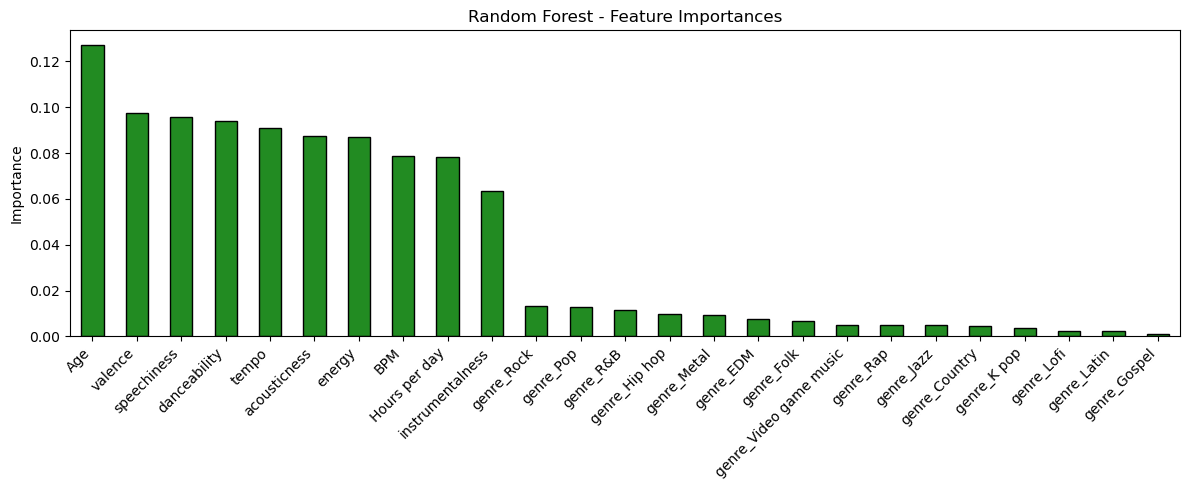

In [158]:
importances_rf = pd.Series(rf_best.feature_importances_, index= featureCols).sort_values(ascending=False)

plt.figure(figsize=(12,5))
importances_rf.plot(kind = 'bar', color = 'forestgreen', edgecolor = 'black')
plt.title('Random Forest - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

COMPARING THE ALL MODELS

In [159]:
models = {
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'KNN':           (y_pred_knn, y_prob_knn),
    'Random Forest': (y_pred_rf,  y_prob_rf)
}

rows = []
for name, (y_pred, y_prob) in models.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC AUC':   roc_auc_score(y_test, y_prob)
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
print(comparison.to_string())


               Accuracy  Precision  Recall      F1  ROC AUC
Model                                                      
Decision Tree     0.512     0.6364  0.4605  0.5344   0.5518
KNN               0.584     0.6200  0.8158  0.7045   0.5541
Random Forest     0.584     0.6277  0.7763  0.6941   0.5910


NOW MOVING ON TO REGRESSION, OUR GOAL IS NOT BINARY ENCODING AND PREDICTING ANXIETY OF THE PARTICIPANT BASED ON THEIR MUSICIAL TASTE BUT NOW OUR MAING GOAL IS PREDICTIONG THE ANXIETY SCORE IN RANGE 0 TO 10

In [160]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_ml2 = pd.concat([merged[audio_features + survey_features + ['Anxiety']], genreDummies], axis=1)
df_ml2 = df_ml2.dropna()
featureCols2 = audio_features + survey_features + list(genreDummies.columns)


y_reg = df_ml2['Anxiety']
x_reg = df_ml2[featureCols2]

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size = 0.2, random_state=42)

scaler_reg = StandardScaler()
x_train_reg_scaled = scaler_reg.fit_transform(x_train_reg)
x_test_reg_scaled = scaler_reg.transform(x_test_reg)

print(f"Train: {x_train_reg.shape}, Test: {x_test_reg.shape}")


Train: (496, 25), Test: (125, 25)


NOW MAKING THE LINEAR REGRESSION

In [161]:
lr = LinearRegression()
lr.fit(x_train_reg_scaled, y_train_reg)

y_pred_lr = lr.predict(x_test_reg_scaled)

mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("=== Linear Regression — Test Set Results ===")
print(f"MSE:  {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

=== Linear Regression — Test Set Results ===
MSE:  7.7152
RMSE: 2.7776
R²:   0.0593


In [162]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)
rf_reg_param_grid = {'n_estimators' : [50,100,200],'max_depth' : [3,5,10,None]}

rf_reg_grid = GridSearchCV(rf_reg, rf_reg_param_grid, cv=5, scoring ='neg_mean_squared_error', n_jobs=1)
rf_reg_grid.fit(x_train_reg, y_train_reg)

print(f"Best params: {rf_reg_grid.best_params_}")
print(f"Best CV MSE: {-rf_reg_grid.best_score_:.4f}")

Best params: {'max_depth': 3, 'n_estimators': 50}
Best CV MSE: 7.3027


In [163]:
rf_reg_best = rf_reg_grid.best_estimator_
y_pred_rf_reg = rf_reg_best.predict(x_test_reg)

mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("***** RANDOM FOREST REGRESSOR TEST RESULTS****")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

***** RANDOM FOREST REGRESSOR TEST RESULTS****
MSE:  7.5515
RMSE: 2.7480
R²:   0.0792


BOTH R2 VALUES ARE LOW THEY ARE NOT EVEN 8% BUT STILL IT IS A GOOD IDEA TO DRAW A COMPARING GRAPH

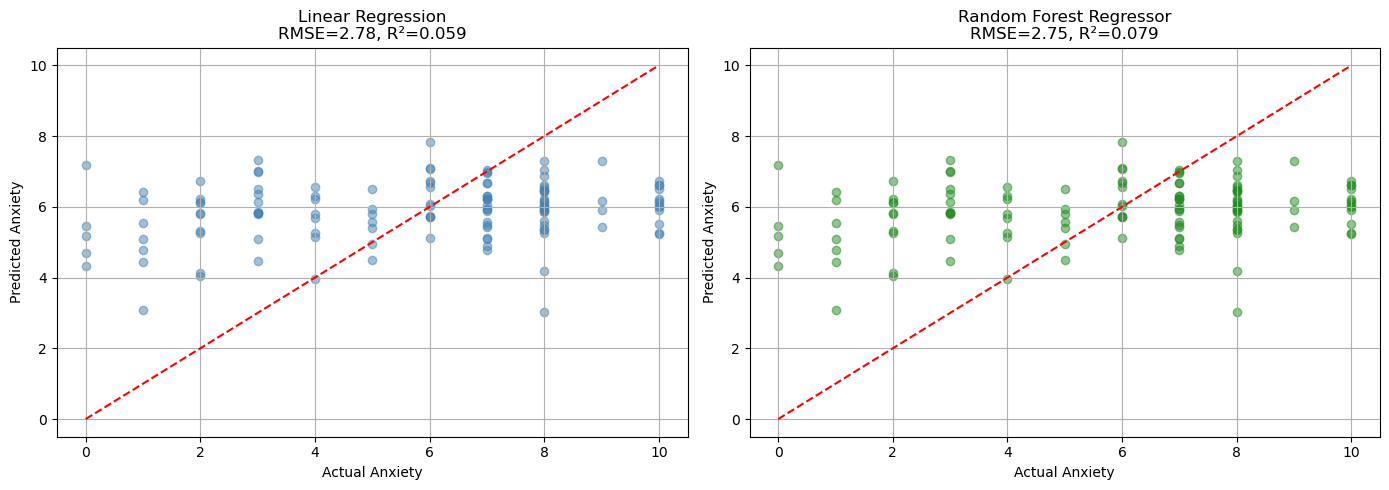

In [164]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

#Linear Regression: Actual vs Predicted
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([0,10], [0,10], 'r--')
axes[0].set_xlabel('Actual Anxiety')
axes[0].set_ylabel('Predicted Anxiety')
axes[0].set_title(f'Linear Regression\nRMSE={rmse_lr:.2f}, R²={r2_lr:.3f}')
axes[0].grid(True)

#Random Forest: Actual vs Predicted
axes[1].scatter(y_test_reg, y_pred_lr, alpha=0.5, color='forestgreen')
axes[1].plot([0,10], [0,10], 'r--')
axes[1].set_xlabel('Actual Anxiety')
axes[1].set_ylabel('Predicted Anxiety')
axes[1].set_title(f'Random Forest Regressor\nRMSE={rmse_rf:.2f}, R²={r2_rf:.3f}')
axes[1].grid(True)

plt.tight_layout()
plt.show()

NOW CLUSTERING, THE K MEANS CLUSTERING IS GOING TO BE USED, WE ARE TRYING TO EXPLORE PARTICIPANTS PROFILES. IN THE FINAL WE ARE GOING TO FIND THE ANXIETY AVERAGE OF THE EVERY TYPE

In [169]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = audio_features + survey_features

df_cluster = merged[cluster_features].dropna()

scaler_cl = StandardScaler()
x_cluster_scaled = scaler_cl.fit_transform(df_cluster)

print(f"Clustering dataset shape: {df_cluster.shape}")


Clustering dataset shape: (621, 10)


FINDING THE BEST K WITH ELBOW METHOD AND SILHOUETTE SCORE

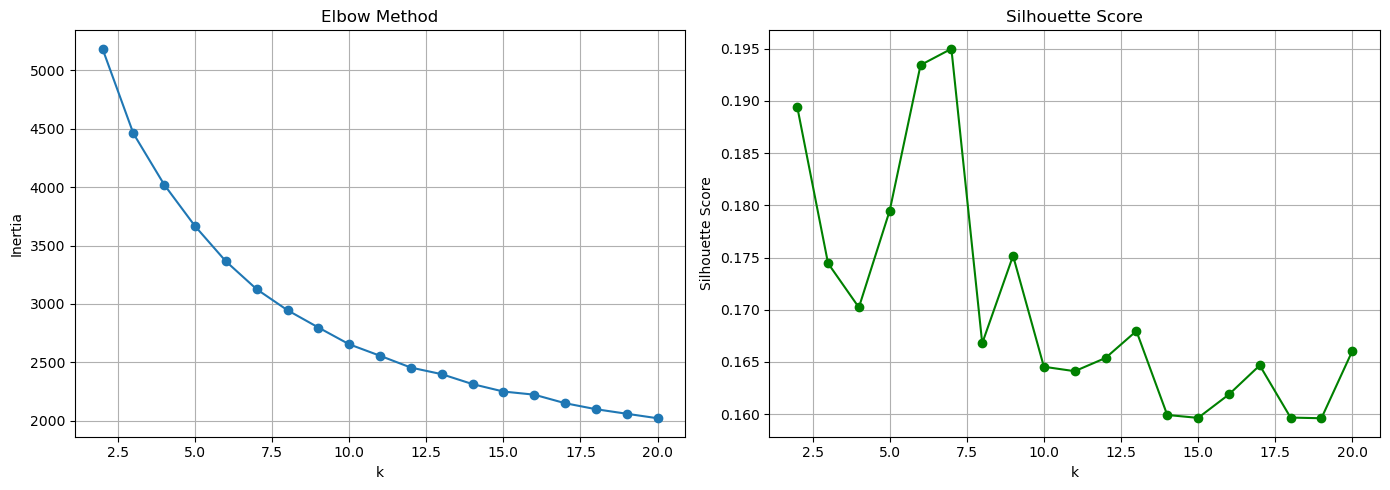

In [172]:
inertias = []
silhouettes = []
k_values = range(2,21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(x_cluster_scaled, labels))

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(list(k_values), silhouettes, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()




In [173]:
best_k_cl = 3

kmeans = KMeans(n_clusters=best_k_cl, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(x_cluster_scaled)

print("Cluster distribution:")
print(df_cluster['cluster'].value_counts())


Cluster distribution:
cluster
1    315
0    177
2    129
Name: count, dtype: int64


We found 3 clusters, now we are looking to mental health average of each cluster

In [174]:
df_cluster['Anxiety'] = merged.loc[df_cluster.index, 'Anxiety']
df_cluster['Depression'] = merged.loc[df_cluster.index, 'Depression']
df_cluster['Insomnia'] = merged.loc[df_cluster.index, 'Insomnia']

#Avg of each cluster
cluster_summary = df_cluster.groupby('cluster')[audio_features + survey_features + ['Anxiety', 'Depression', 'Insomnia']].mean().round(2)
print(cluster_summary)

         valence  energy  danceability  acousticness  instrumentalness  \
cluster                                                                  
0           0.43    0.74          0.52          0.11              0.02   
1           0.58    0.70          0.68          0.16              0.03   
2           0.35    0.36          0.53          0.72              0.27   

         speechiness   tempo    Age  Hours per day     BPM  Anxiety  \
cluster                                                               
0               0.09  160.59  25.25           3.74  160.97     5.89   
1               0.07  109.19  24.37           3.93  109.14     5.88   
2               0.04  108.38  24.36           3.19  108.39     5.74   

         Depression  Insomnia  
cluster                        
0              5.07      4.01  
1              4.73      3.73  
2              4.90      3.72  


NOW VISUALIZE THE CLUSTERS

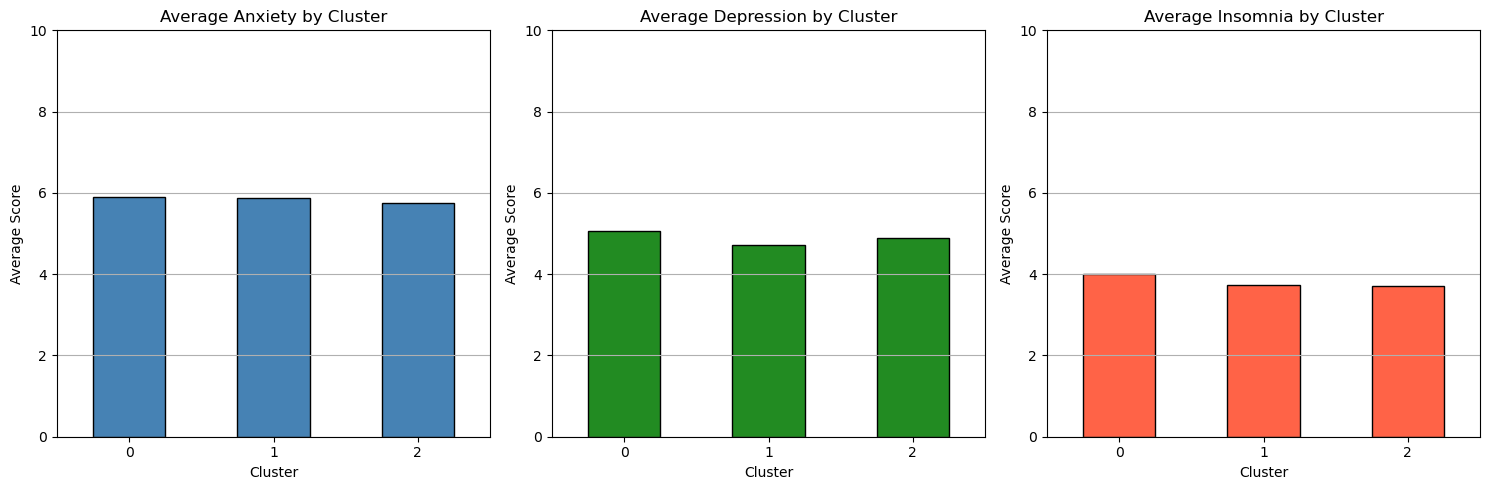

In [176]:
fig,axes = plt.subplots(1,3, figsize=(15,5))

metrics = ['Anxiety', 'Depression', 'Insomnia']
colors = ['steelblue', 'forestgreen', 'tomato']

for ax, metric, color in zip(axes, metrics, colors):
    cluster_summary[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Average {metric} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Average Score')
    ax.set_ylim(0, 10)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

